## 1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from itertools import count
from typing import Any, Dict, Iterable, List, Optional, Tuple
import heapq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 2. The Abstract Problem Interface

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

## 3. The Node Class

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

## 4. Helper Functions

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

## 5. Implementing the Grid Search problem

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: Optional[List[List[float]]] = None,
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).

        terrain_costs:
            Optional 2D list of movement costs. If terrain_costs is None,
            every valid movement costs 1.
        """
        self.grid = grid
        self.start = start
        self.goal = goal
        self.terrain_costs = terrain_costs

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal  # Return True if state is equal to the goal state.

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # Create an empty list called legal_actions.
        legal_actions = []

        # 2. For each action in MOVES:
        for action in MOVES:
            dr, dc = MOVES[action]
            neighbour = (state[0] + dr, state[1] + dc)  # Compute the neighbour cell.

            if self.in_bounds(neighbour):  # Check that it is in bounds.
                if self.is_free(neighbour):  # Check that it is free.
                    legal_actions.append(
                        action
                    )  # If valid, add the action name to legal_actions.

        # 3. Return legal_actions.
        return legal_actions  # Return a list of legal action names.

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        return (
            state[0] + dr,
            state[1] + dc,
        )  # Return the next state after applying action to state.

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO: Return the cost of applying action in state to reach next_state.
        row, col = next_state
        if self.terrain_costs is None:  # If terrain_costs is None, return 1.
            return 1
        else:
            return self.terrain_costs[row][
                col
            ]  # Otherwise, return the cost of ENTERING next_state.

5.1 Self-Check for Grid Problem

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


## 6. Sample Drone Map

In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

## 7. Visualisation Helper

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

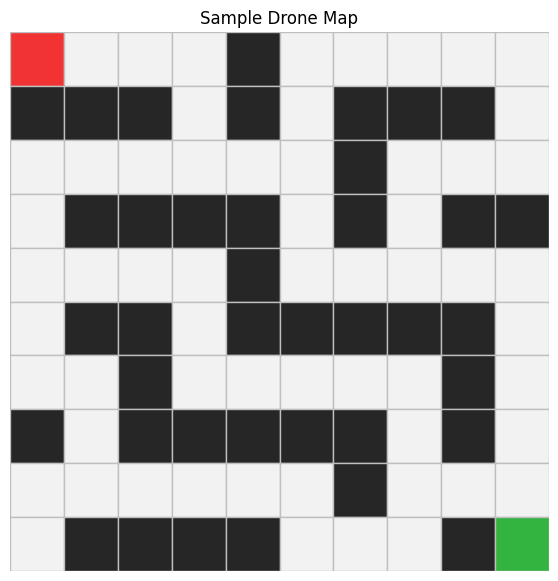

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

## 8. The Shared expand Method

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # Implementing the AIMA-style EXPAND(problem, node) from the pseudocode.

        s = node.state  # Get the state from the node
        for action in problem.actions(s):
            s_prime = problem.result(s, action)  # Compute the next state
            cost = node.path_cost + problem.action_cost(
                s, action, s_prime
            )  # Compute the cost of path to the next state
            yield Node(
                state=s_prime, parent=node, action=action, path_cost=cost
            )  # Yield a new node with the next state, the current node as parent, the action, and the path cost.

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

## 9. Breadth-First Search (BFS)

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # Implement BFS graph search using a FIFO queue.

        # Create the initial node from problem.initial_state().
        initial_node = Node(state=problem.initial_state())

        # If the initial state is the goal, return success.
        if initial_node.state == problem.goal:
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        # Create a deque frontier and add the initial node.
        frontier = deque([initial_node])

        # Create a reached set and add the initial state.
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        # While frontier is not empty:
        while frontier:
            node = frontier.popleft()  # pop from the LEFT of the deque.
            nodes_expanded += 1  # increment nodes_expanded.
            children = self.expand(problem, node)  # expand the node.

            for child in children:  # for each child
                if child.state == problem.goal:  # if child is goal, return success.
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=len(frontier),
                        reached_count=len(reached),
                    )
                elif child.state not in reached:  # if child.state is not in reached:
                    reached.add(child.state)
                    frontier.append(child)

        # update max_frontier_size.
        max_frontier_size = max(max_frontier_size, len(frontier))

        # Return failure if no solution is found.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

## 10. Depth-First Search (DFS)

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # Implement DFS graph search using a stack.

        # Create the initial node.
        initial_node = Node(state=problem.initial_state())

        # If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        # Use a Python list as the stack frontier.
        frontier = [initial_node]

        # Use a reached set.
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        # While frontier is not empty:
        while frontier:
            node = frontier.pop()  # pop from the end of the list.
            nodes_expanded += 1  # increment nodes_expanded.

            # add unreached children to the stack.
            for child in self.expand(problem, node):  # expand the node.
                if child.state not in reached:
                    if problem.is_goal(child.state):
                        return SearchResult(
                            algorithm=algorithm,
                            status="success",
                            solution=child,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size=max_frontier_size,
                            reached_count=len(reached),
                        )
                    reached.add(child.state)
                    frontier.append(child)

            # update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

## 11. Depth-Limited Search

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # Implement recursive depth-limited search.

        # If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return node, "success"

        # Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return None, "cutoff"

        # Otherwise:
        else:
            metrics["nodes_expanded"] += 1  # increment metrics["nodes_expanded"].
            cutoff_occurred = False  # set cutoff_occurred = False.

            path_states = set()
            current = node
            while current is not None:
                path_states.add(current.state)
                current = current.parent

            for child in self.expand(
                problem, node
            ):  # for each child in expand(problem, node):
                if (
                    child.state in path_states
                ):  # if child.state already appears on the current path, skip the child.
                    continue  # skip the child if child.state already appears on the current path.

                metrics["max_stack_size"] = max(
                    metrics["max_stack_size"], current_stack_size + 1
                )  # update max_stack_size.

                result, status = (
                    self._recursive_dls(  # recursively call _recursive_dls on the child.
                        problem=problem,
                        node=child,
                        limit=limit,
                        metrics=metrics,
                        current_stack_size=current_stack_size + 1,
                    )
                )

                if (
                    status == "success"
                ):  # if result is "success", return success immediately.
                    return result, "success"

                elif (
                    status == "cutoff"
                ):  # if result is "cutoff", set cutoff_occurred = True.
                    cutoff_occurred = True

            # after all children:
            if cutoff_occurred:
                return None, "cutoff"  # if cutoff_occurred, return (None, "cutoff")

            else:
                return None, "failure"  # else return (None, "failure")

## 12. Iterative Deepening Search (IDS)

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        # Keep a list called iteration_log.
        iteration_log = []
        total_nodes_expanded = 0
        dls = DepthLimitedSearch()
        max_stack = 0

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            total_nodes_expanded += (
                result.nodes_expanded
            )  # Accumulate total nodes expanded across all DLS iterations.
            max_stack = max(
                max_stack, result.max_frontier_size
            )  # Track the maximum stack size seen in any DLS run.

            iteration_log.append({"limit": limit, "status": result.status})

            if (
                result.status == "success"
            ):  # If a DLS run returns success, return a SearchResult for IDS.
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack,
                    reached_count=0,
                    limit=limit,
                )
            elif (
                result.status == "failure"
            ):  # If a DLS run returns failure, IDS can stop early and return failure.
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack,
                    reached_count=0,
                    limit=limit,
                )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack,
            reached_count=0,
            limit=max_depth,
        )


## 13. Uniform Cost Search

In [15]:
class UniformCostSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "UCS"

        # Implement UCS using heapq.
        initial_node = Node(problem.initial_state())  # Create initial node.

        frontier = []  # Create frontier as an empty list.

        counter = count()  # Use itertools.count() for a tie breaker.

        heapq.heappush(
            frontier, (0, next(counter), initial_node)
        )  # Push (0, next(counter), initial_node) onto the heap.

        reached_cost = {}  # Create a dictionary reached_cost where reached_cost[state] = cheapest known cost to reach state
        reached_cost[initial_node.state] = 0

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:  # While frontier is not empty:
            _, _, node = heapq.heappop(
                frontier
            )  # pop the node with the smallest path cost.

            if node.path_cost > reached_cost.get(
                node.state, float("inf")
            ):  # if this node is outdated, skip it.
                continue

            if problem.is_goal(node.state):  # if node.state is goal, return success.
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached_cost),
                )
            nodes_expanded += 1  # increment nodes_expanded.

            # for each child, expand the node
            for child in self.expand(problem, node):
                # if child.state is new OR child.path_cost is cheaper:
                if (
                    child.state not in reached_cost
                    or child.path_cost < reached_cost[child.state]
                ):
                    reached_cost[child.state] = child.path_cost  # update reached_cost.
                    heapq.heappush(
                        frontier, (child.path_cost, next(counter), child)
                    )  # push child onto the priority queue.

            max_frontier_size = max(
                max_frontier_size, len(frontier)
            )  # update max_frontier_size.

        # Return failure.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached_cost),
        )

## 14. Run the Algorithms on the Sample Map

In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()
ucs = UniformCostSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
    ucs.search(problem),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,2,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0
4,UCS,success,NaN,18.0,18.0,52,5,56


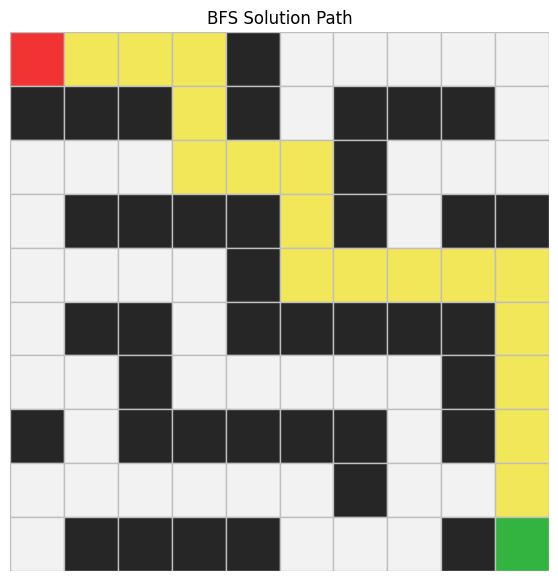

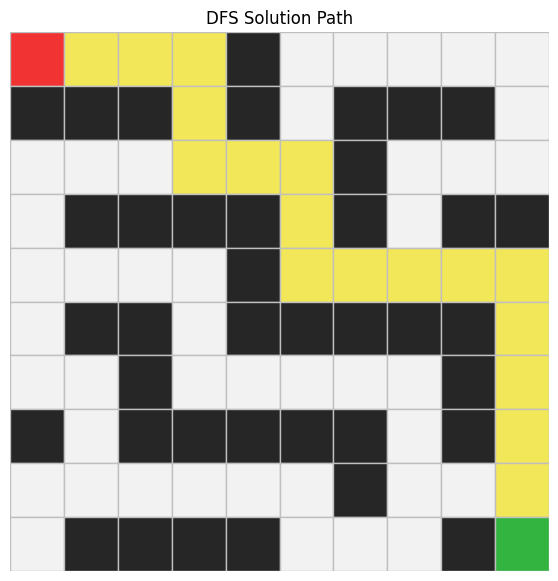

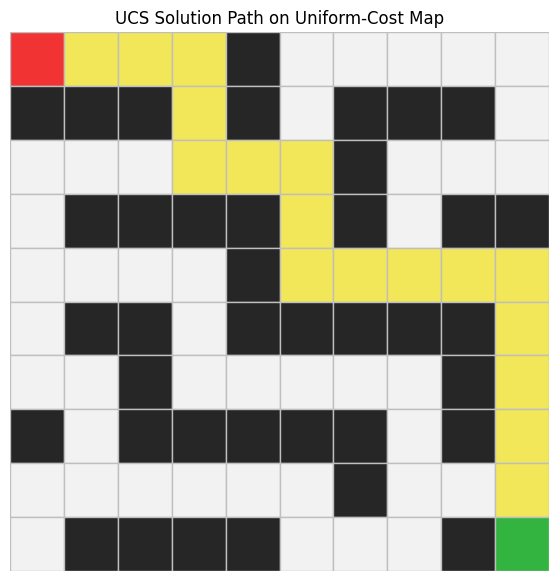

In [17]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
ucs_result = results[4]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path(),
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path(),
    title="DFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ucs_result.path(),
    title="UCS Solution Path on Uniform-Cost Map",
)

## 15. Weighted Terrain for UCS

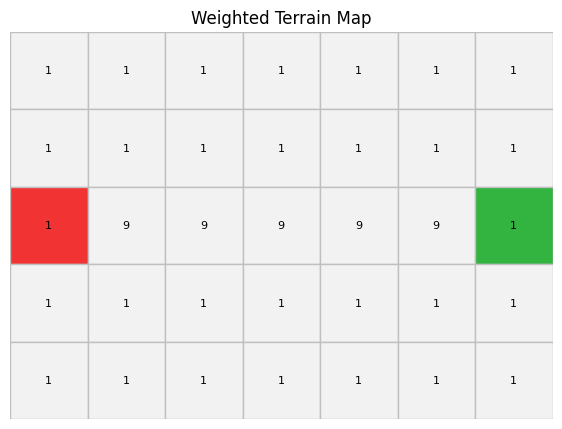

In [18]:
weighted_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

weighted_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 9, 9, 9, 9, 9, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

weighted_start = (2, 0)
weighted_goal = (2, 6)

weighted_problem = GridProblem(
    grid=weighted_grid,
    start=weighted_start,
    goal=weighted_goal,
    terrain_costs=weighted_costs,
)

plot_path(
    weighted_grid,
    weighted_start,
    weighted_goal,
    terrain_costs=weighted_costs,
    title="Weighted Terrain Map",
)

In [19]:
weighted_results = [
    bfs.search(weighted_problem),
    dfs.search(weighted_problem),
    ucs.search(weighted_problem),
]

show_results(weighted_results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,None,6,46,24,4,28
1,DFS,success,None,6,46,6,11,18
2,UCS,success,None,8,8,28,9,35


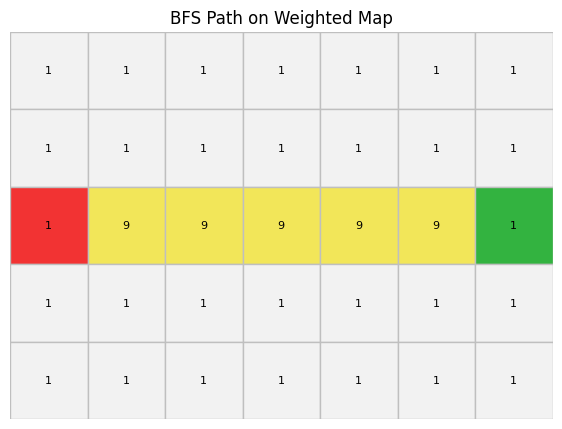

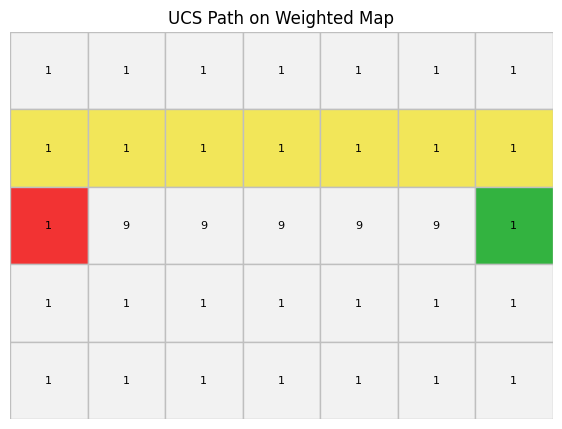

In [20]:
# Compare BFS and UCS paths on the weighted map.

weighted_bfs_result = weighted_results[0]
weighted_ucs_result = weighted_results[2]

plot_path(
    weighted_grid,
    weighted_start,
    weighted_goal,
    path=weighted_bfs_result.path(),
    terrain_costs=weighted_costs,
    title="BFS Path on Weighted Map",
)

plot_path(
    weighted_grid,
    weighted_start,
    weighted_goal,
    path=weighted_ucs_result.path(),
    terrain_costs=weighted_costs,
    title="UCS Path on Weighted Map",
)

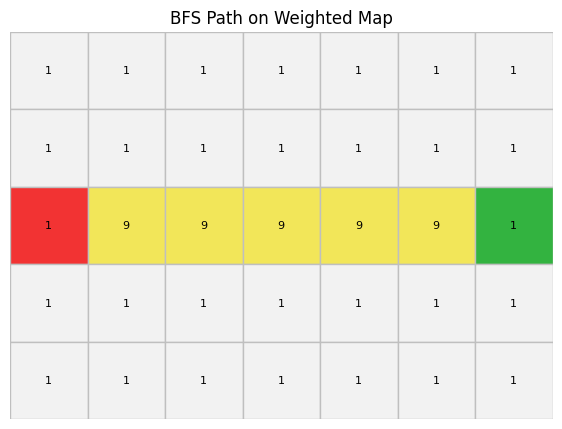

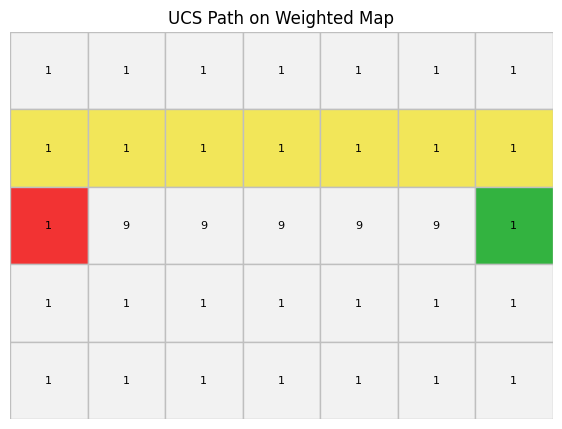

In [21]:
# Compare BFS and UCS paths on the weighted map.

weighted_bfs_result = weighted_results[0]
weighted_ucs_result = weighted_results[2]

plot_path(
    weighted_grid,
    weighted_start,
    weighted_goal,
    path=weighted_bfs_result.path(),
    terrain_costs=weighted_costs,
    title="BFS Path on Weighted Map",
)

plot_path(
    weighted_grid,
    weighted_start,
    weighted_goal,
    path=weighted_ucs_result.path(),
    terrain_costs=weighted_costs,
    title="UCS Path on Weighted Map",
)

## 16. Create Your Own Maps

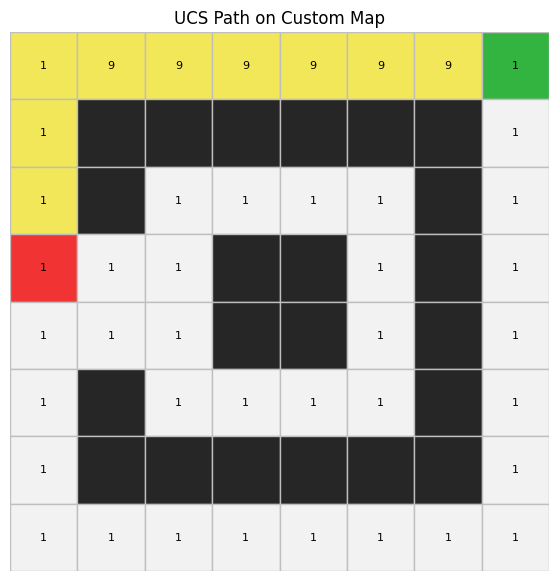

In [22]:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
]

custom_weighted_costs_1 = [
    [1, 9, 9, 9, 9, 9, 9, 1],  # top row — direct but expensive
    [1, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 1, 1, 1, 1, 9, 1],
    [1, 1, 1, 9, 9, 1, 9, 1],
    [1, 1, 1, 9, 9, 1, 9, 1],
    [1, 9, 1, 1, 1, 1, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],  # bottom row — longer but cheap
]

custom_start_1 = (3, 0)
custom_goal_1 = (0, 7)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
    ucs.search(custom_problem_1),
]
show_results(custom_results_1)

ucs_custom_results_1 = custom_results_1[4]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=ucs_custom_results_1.path(),
    terrain_costs=custom_weighted_costs_1,
    title="UCS Path on Custom Map",
)

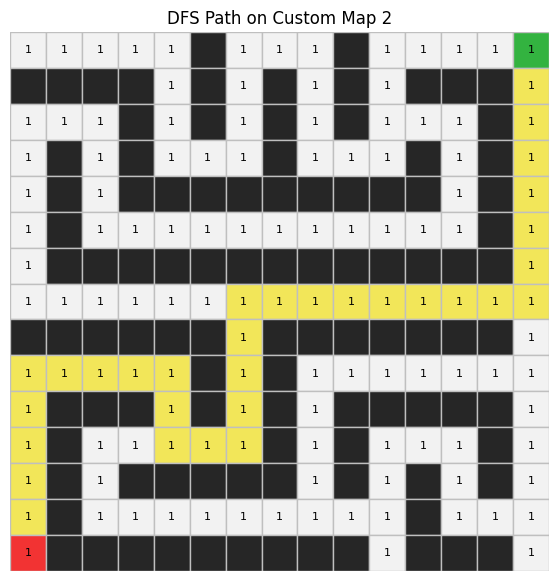

In [23]:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
]

custom_weighted_costs_2 = [
    [1, 1, 1, 1, 1, 9, 1, 1, 1, 9, 1, 1, 1, 1, 1],
    [9, 9, 9, 9, 1, 9, 1, 9, 1, 9, 1, 9, 9, 9, 1],
    [1, 1, 1, 9, 1, 9, 1, 9, 1, 9, 1, 1, 1, 9, 1],
    [1, 9, 1, 9, 1, 1, 1, 9, 1, 1, 1, 9, 1, 9, 1],
    [1, 9, 1, 9, 9, 9, 9, 9, 9, 9, 9, 9, 1, 9, 1],
    [1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [9, 9, 9, 9, 9, 9, 1, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 1, 1, 1, 1, 9, 1, 9, 1, 1, 1, 1, 1, 1, 1],
    [1, 9, 9, 9, 1, 9, 1, 9, 1, 9, 9, 9, 9, 9, 1],
    [1, 9, 1, 1, 1, 1, 1, 9, 1, 9, 1, 1, 1, 9, 1],
    [1, 9, 1, 9, 9, 9, 9, 9, 1, 9, 1, 9, 1, 9, 1],
    [1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 1, 1, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 9, 1, 9, 9, 9, 1],
]

custom_start_2 = (14, 0)
custom_goal_2 = (0, 14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
    ucs.search(custom_problem_2),
]
show_results(custom_results_2)

dfs_custom_results_2 = custom_results_2[1]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_custom_results_2.path(),
    terrain_costs=custom_weighted_costs_2,
    title="DFS Path on Custom Map 2",
)

## 17. Reflection Questions

17.1 Problem Formulation

1. What is a state in this lab?
Ans: A cell in a grid (tuple)

2. What is an action?
Ans: Moveing in any direction whether up, down, left or right

3. What does the `result` function do?
Ans: Takes a state an action then returns a new state after applying that 'valid' action

4. Why is it useful to separate the problem definition from the search algorithm?
Ans: Helps use the same search algorithm for a different problem

17.2 BFS

1. Why does BFS use a FIFO queue?
Ans: The algorithm is forced to go through and process all nodes at a level before moving deeper

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Ans: Since it goes level by level, it ensures the first path to the goal and hence the shortest

3. Why can BFS fail to find the cheapest path when terrain costs vary?
Ans: BFS completely ignores the costs of movements, only because it cares about optimizing steps

17.3 DFS

1. Why does DFS use a stack?
Ans: To backtrack from a branch after exploring the most recently discovered nodes

2. Is DFS guaranteed to find the shortest path? Explain.
Ans: No, if a branch is infinitely long it would not stop and continue searching

3. Under what conditions can DFS use less memory than BFS?
Ans: Only if a node has multiple branches and the graph has a low depth

4. Under what conditions can DFS perform badly?
Ans: In deep or infinite search spaces

17.4 DLS

1. What happens when the depth limit is too small?
Ans: The search might miss the goal and go to another path that doesn't have the solution

2. What is the meaning of `"cutoff"`?
Ans: The algorithm does not continue searching after it reaches a level in a branch to try and save cost

3. How is DLS different from ordinary DFS?
Ans: DLS terminates a branch when a search in a particular branch exceeds a certain limit, whereas a DFS will unconditionally go through a whole branch until a solution is found or not 

4. Why do we use path-cycle checking in DLS?
Ans: To elimate redundant explorations and also prevent the algorithm from entering infinite loops

17.5 IDS

1. Why does IDS repeat DLS with increasing limits?
Ans: IDS uses the stack-based structure of DFS to conserve memory and gradually increases the depth limit

2. Why can IDS be complete even though DLS with a small limit is not?
Ans: It overcomes the depth limit by continuously incrementing it, as long as the goal exists at that depth

3. Why does IDS use less memory than BFS?
Ans: IDS runs DLS using a stack making its memory linear

4. What is the cost of repeatedly searching from the root?
Ans: Regenerating upper-level nodes multiple times because it's always bound to happen

17.6 UCS

1. Why does UCS use a priority queue?
Ans: To organise nodes in ascending order based on their total path cost 

2. What does UCS use as its evaluation value?
Ans: Path cost, g(n)

3. Why is UCS optimal when all action costs are non-negative?
Ans: It expands nodes in order of increasing path cost, therefore, when a goal node is selected for expansion, no other unexpanded path can ever be cheaper 

4. Compare the BFS and UCS paths on the weighted map. Which path is cheaper and why?
Ans: UCS because BFS only minimises the number of steps not the total cost compared to UCS which seeks to minimise total cost

17.7 Real-World Drone Context

1. In a real drone application, what might make one cell more costly than another?
Ans: If it requires the drone to use more battery power for elevation or having to manoeuver through impeding structures

2. Which algorithm would you choose for a drone that must minimise battery consumption? Explain.
Ans: UCS search because the drone is not working with any knowledge. Since battery is now a constraint, UCS will expand paths that consume the absolute lowest battery life first and be more decisively

3. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves?
Ans: Breadth First Search (BFS)

4. What limitations does this grid model have compared with real drone navigation?
Ans: There are many varying factors that may not have been accounted for during modeling the grid, i.e, a grid may have a higher cost from winds, hidden walls, etc. Additionally, transitioning from one grid to another may be sharper